# Module 3: Fundamentals of Statistical Learning

## Milestone 1 - Exploration phase

**Objective**: Build a predictive model to identify users likely to purchase a promoted product via push notification. Only orders with 5+ items are relevant (shipping cost constraint from the sales team).

**Approach**: Linear models evaluated with train/validation/test temporal split. PR-AUC as primary metric due to extreme class imbalance (~1.4% positive rate).

**Data**: `feature_frame.csv` — each row is an (order, product) pair where `outcome` indicates whether the product was purchased.

In [2]:
import pandas as pd
import numpy as np

DATA_PATH = "../../data/raw/feature_frame.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (2880549, 27)
Columns: ['variant_id', 'product_type', 'order_id', 'user_id', 'created_at', 'order_date', 'user_order_seq', 'outcome', 'ordered_before', 'abandoned_before', 'active_snoozed', 'set_as_regular', 'normalised_price', 'discount_pct', 'vendor', 'global_popularity', 'count_adults', 'count_children', 'count_babies', 'count_pets', 'people_ex_baby', 'days_since_purchase_variant_id', 'avg_days_to_buy_variant_id', 'std_days_to_buy_variant_id', 'days_since_purchase_product_type', 'avg_days_to_buy_product_type', 'std_days_to_buy_product_type']


,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


## Data loading and filtering

We filter orders to keep only those with at least 5 items purchased (`outcome == 1`), as required by the sales team. Smaller baskets don't cover shipping costs.

In [3]:
# Convert order_date to datetime for later temporal split
df["order_date"] = pd.to_datetime(df["order_date"])

# Count items actually purchased per order (outcome == 1)
items_per_order = df[df["outcome"] == 1].groupby("order_id").size()
print(f"Total unique orders: {items_per_order.shape[0]}")
print(f"Basket size distribution:")
print(items_per_order.describe())

# Keep only orders with at least 5 items purchased
valid_orders = items_per_order[items_per_order >= 5].index
df_filtered = df[df["order_id"].isin(valid_orders)].copy()

print(f"\nOriginal shape: {df.shape}")
print(f"Filtered shape: {df_filtered.shape}")
print(f"Rows removed: {df.shape[0] - df_filtered.shape[0]:,}")
print(f"Positive rate after filter: {df_filtered['outcome'].mean():.4f}")

Total unique orders: 3427
Basket size distribution:
count    3427.000000
mean        9.697111
std         6.789204
min         1.000000
25%         5.000000
50%         9.000000
75%        13.000000
max        78.000000
dtype: float64

Original shape: (2880549, 27)
Filtered shape: (2163953, 27)
Rows removed: 716,596
Positive rate after filter: 0.0145


In [4]:
# Explore temporal distribution of orders (not rows, orders)
orders_temporal = df_filtered.groupby("order_id")["order_date"].first().sort_values()

print(f"Date range: {orders_temporal.min()} to {orders_temporal.max()}")
print(f"Total span: {(orders_temporal.max() - orders_temporal.min()).days} days")
print(f"Total orders after filter: {orders_temporal.shape[0]}")

# Orders per month to see volume distribution
orders_per_month = orders_temporal.dt.to_period("M").value_counts().sort_index()
print(f"\nOrders per month:")
print(orders_per_month)

Date range: 2020-10-05 00:00:00 to 2021-03-03 00:00:00
Total span: 149 days
Total orders after filter: 2603

Orders per month:
order_date
2020-10    210
2020-11    357
2020-12    419
2021-01    707
2021-02    829
2021-03     81
Freq: M, Name: count, dtype: int64


## Temporal split
Split by calendar months to avoid information leakage. Train: Oct-Dec 2020 | Val: Jan 2021 | Test: Feb-Mar 2021.

In [5]:
# Temporal split by calendar months
# Train: Oct-Dec 2020 | Val: Jan 2021 | Test: Feb-Mar 2021
train_mask = df_filtered["order_date"] < "2021-01-01"
val_mask = (df_filtered["order_date"] >= "2021-01-01") & (df_filtered["order_date"] < "2021-02-01")
test_mask = df_filtered["order_date"] >= "2021-02-01"

df_train = df_filtered[train_mask].copy()
df_val = df_filtered[val_mask].copy()
df_test = df_filtered[test_mask].copy()

# Sanity checks
print("=== Split sizes ===")
print(f"Train: {df_train.shape[0]:>10,} rows | {df_train['order_id'].nunique():>5} orders | dates: {df_train['order_date'].min().date()} → {df_train['order_date'].max().date()}")
print(f"Val:   {df_val.shape[0]:>10,} rows | {df_val['order_id'].nunique():>5} orders | dates: {df_val['order_date'].min().date()} → {df_val['order_date'].max().date()}")
print(f"Test:  {df_test.shape[0]:>10,} rows | {df_test['order_id'].nunique():>5} orders | dates: {df_test['order_date'].min().date()} → {df_test['order_date'].max().date()}")

# Check that positive rate is consistent across splits
print("\n=== Positive rate (outcome == 1) ===")
print(f"Train: {df_train['outcome'].mean():.4f}")
print(f"Val:   {df_val['outcome'].mean():.4f}")
print(f"Test:  {df_test['outcome'].mean():.4f}")

# Check no overlap in order_ids across splits (leakage check)
train_orders = set(df_train["order_id"])
val_orders = set(df_val["order_id"])
test_orders = set(df_test["order_id"])

print("\n=== Leakage check (should all be 0) ===")
print(f"Train ∩ Val:  {len(train_orders & val_orders)}")
print(f"Train ∩ Test: {len(train_orders & test_orders)}")
print(f"Val ∩ Test:   {len(val_orders & test_orders)}")

=== Split sizes ===
Train:    734,405 rows |   986 orders | dates: 2020-10-05 → 2020-12-31
Val:      599,217 rows |   707 orders | dates: 2021-01-01 → 2021-01-31
Test:     830,331 rows |   910 orders | dates: 2021-02-01 → 2021-03-03

=== Positive rate (outcome == 1) ===
Train: 0.0165
Val:   0.0138
Test:  0.0132

=== Leakage check (should all be 0) ===
Train ∩ Val:  0
Train ∩ Test: 0
Val ∩ Test:   0


In [6]:
# Identify columns that are NOT features
id_cols = ["variant_id", "order_id", "user_id", "created_at", "order_date"]
categorical_cols = ["product_type", "vendor"]
target_col = "outcome"

# Feature columns = everything else
feature_cols = [
    c for c in df_filtered.columns
    if c not in id_cols + categorical_cols + [target_col]
]

print(f"Target: {target_col}")
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Build X and y for each split
X_train, y_train = df_train[feature_cols], df_train[target_col]
X_val, y_val = df_val[feature_cols], df_val[target_col]
X_test, y_test = df_test[feature_cols], df_test[target_col]

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# Check for missing values
print(f"\nMissing values in X_train:")
missing = X_train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None")

Target: outcome
Number of features: 19
Features: ['user_order_seq', 'ordered_before', 'abandoned_before', 'active_snoozed', 'set_as_regular', 'normalised_price', 'discount_pct', 'global_popularity', 'count_adults', 'count_children', 'count_babies', 'count_pets', 'people_ex_baby', 'days_since_purchase_variant_id', 'avg_days_to_buy_variant_id', 'std_days_to_buy_variant_id', 'days_since_purchase_product_type', 'avg_days_to_buy_product_type', 'std_days_to_buy_product_type']

X_train shape: (734405, 19)
X_val shape:   (599217, 19)
X_test shape:  (830331, 19)

Missing values in X_train:
None


## Modeling
Baseline Logistic Regression + comparison of L1/L2 regularization with different C values. PR-AUC as primary metric due to class imbalance (~1.4% positive rate).

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
import matplotlib.pyplot as plt

# Baseline pipeline: scaling + logistic regression
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

baseline.fit(X_train, y_train)

# Predict probabilities on validation set
y_val_proba = baseline.predict_proba(X_val)[:, 1]

# Compute metrics
pr_auc = average_precision_score(y_val, y_val_proba)
roc_auc = roc_auc_score(y_val, y_val_proba)

print(f"=== Baseline Logistic Regression ===")
print(f"Validation PR-AUC:  {pr_auc:.4f}")
print(f"Validation ROC-AUC: {roc_auc:.4f}")
print(f"Baseline (random):  {y_val.mean():.4f}  (positive rate on val)")

=== Baseline Logistic Regression ===
Validation PR-AUC:  0.1335
Validation ROC-AUC: 0.8056
Baseline (random):  0.0138  (positive rate on val)


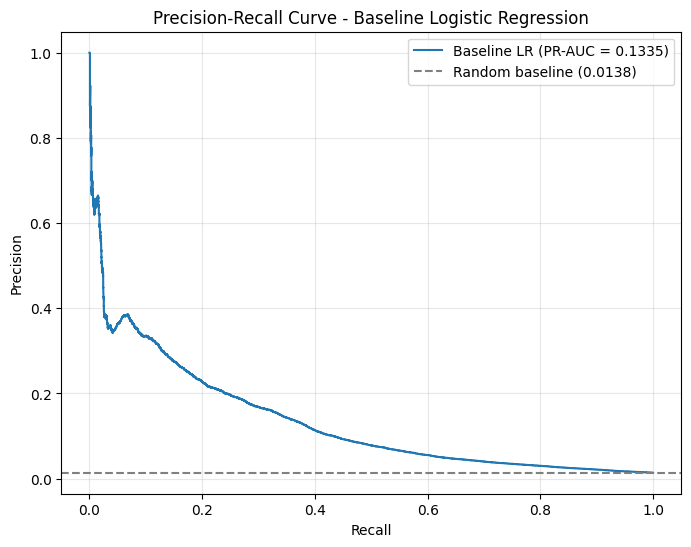

In [8]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, label=f"Baseline LR (PR-AUC = {pr_auc:.4f})")
ax.axhline(
    y=y_val.mean(),
    color="grey",
    linestyle="--",
    label=f"Random baseline ({y_val.mean():.4f})",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Baseline Logistic Regression")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [9]:
# Train multiple LR variants with different regularization settings
configs = [
    ("L2, C=0.01", "l2", 0.01),
    ("L2, C=0.1", "l2", 0.1),
    ("L2, C=1.0", "l2", 1.0),
    ("L2, C=10", "l2", 10.0),
    ("L1, C=0.01", "l1", 0.01),
    ("L1, C=0.1", "l1", 0.1),
    ("L1, C=1.0", "l1", 1.0),
]

results = []

for name, penalty, C in configs:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty=penalty,
            C=C,
            solver="liblinear",  # supports both l1 and l2
            max_iter=1000,
            random_state=42,
        )),
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_val)[:, 1]
    pr = average_precision_score(y_val, proba)
    roc = roc_auc_score(y_val, proba)
    results.append({"model": name, "pr_auc": pr, "roc_auc": roc})
    print(f"{name:15} | PR-AUC: {pr:.4f} | ROC-AUC: {roc:.4f}")

# Also print the baseline for comparison
print(f"{'Baseline (no reg)':15} | PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f}")

L2, C=0.01      | PR-AUC: 0.1340 | ROC-AUC: 0.8076
L2, C=0.1       | PR-AUC: 0.1336 | ROC-AUC: 0.8062
L2, C=1.0       | PR-AUC: 0.1336 | ROC-AUC: 0.8061
L2, C=10        | PR-AUC: 0.1336 | ROC-AUC: 0.8061
L1, C=0.01      | PR-AUC: 0.1341 | ROC-AUC: 0.8079
L1, C=0.1       | PR-AUC: 0.1336 | ROC-AUC: 0.8063
L1, C=1.0       | PR-AUC: 0.1336 | ROC-AUC: 0.8061
Baseline (no reg) | PR-AUC: 0.1335 | ROC-AUC: 0.8056


In [10]:
# Train the winning model and inspect feature importance
best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        C=0.01,
        solver="liblinear",
        max_iter=1000,
        random_state=42,
    )),
])
best_pipe.fit(X_train, y_train)

# Get coefficients
coefs = best_pipe.named_steps["clf"].coef_[0]
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs),
}).sort_values("abs_coefficient", ascending=False)

print("=== Feature importance (Lasso L1, C=0.01) ===")
print(feature_importance.to_string(index=False))

n_zero = (coefs == 0).sum()
print(f"\nFeatures eliminated by L1 (coefficient = 0): {n_zero} / {len(feature_cols)}")

=== Feature importance (Lasso L1, C=0.01) ===
                         feature  coefficient  abs_coefficient
                  ordered_before     0.402444         0.402444
               global_popularity     0.364821         0.364821
                normalised_price    -0.324395         0.324395
                abandoned_before     0.170438         0.170438
                  user_order_seq    -0.081281         0.081281
      avg_days_to_buy_variant_id    -0.030791         0.030791
days_since_purchase_product_type     0.030365         0.030365
                      count_pets     0.024825         0.024825
    avg_days_to_buy_product_type    -0.018453         0.018453
                  set_as_regular     0.018285         0.018285
                    discount_pct     0.015106         0.015106
                    count_adults     0.012985         0.012985
                  count_children    -0.008032         0.008032
  days_since_purchase_variant_id     0.007159         0.007159
         

=== Final Model Evaluation on TEST set ===
Model: Logistic Regression L1, C=0.01
Test PR-AUC:  0.1508
Test ROC-AUC: 0.8206
Test positive rate: 0.0132

=== Validation vs Test comparison ===
            PR-AUC    ROC-AUC
Validation: 0.1341    0.8079
Test:       0.1508    0.8206


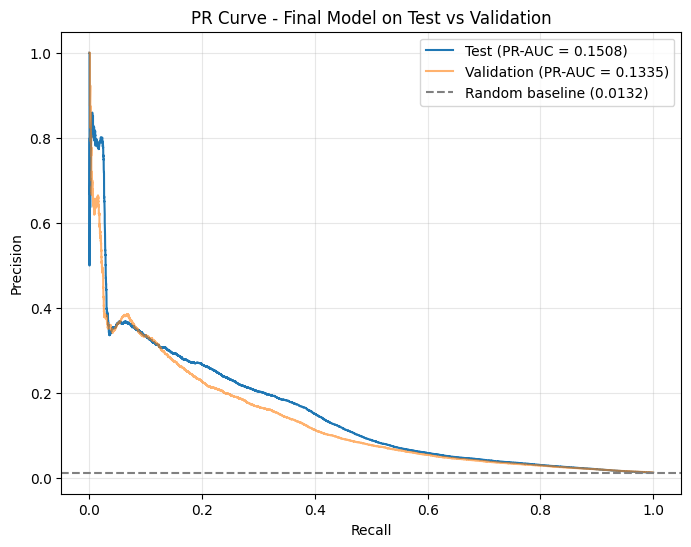

In [11]:
# Final evaluation on TEST set (only do this ONCE)
y_test_proba = best_pipe.predict_proba(X_test)[:, 1]

test_pr_auc = average_precision_score(y_test, y_test_proba)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("=== Final Model Evaluation on TEST set ===")
print(f"Model: Logistic Regression L1, C=0.01")
print(f"Test PR-AUC:  {test_pr_auc:.4f}")
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test positive rate: {y_test.mean():.4f}")

# Compare with validation
print(f"\n=== Validation vs Test comparison ===")
print(f"            PR-AUC    ROC-AUC")
print(f"Validation: {0.1341:.4f}    {0.8079:.4f}")
print(f"Test:       {test_pr_auc:.4f}    {test_roc_auc:.4f}")

# Plot PR curve for test
test_precision, test_recall, _ = precision_recall_curve(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(test_recall, test_precision, label=f"Test (PR-AUC = {test_pr_auc:.4f})")
ax.plot(recall, precision, label=f"Validation (PR-AUC = {pr_auc:.4f})", alpha=0.6)
ax.axhline(
    y=y_test.mean(),
    color="grey",
    linestyle="--",
    label=f"Random baseline ({y_test.mean():.4f})",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR Curve - Final Model on Test vs Validation")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Conclusions
- **Test PR-AUC: 0.1508** (11.4x better than random). Model generalizes well, no overfitting.
- Regularization has minimal impact — bottleneck is feature expressiveness, not model complexity.
- Top predictors: `ordered_before`, `global_popularity`, `normalised_price`, `abandoned_before`.
- L1 eliminated 3/19 features as redundant.
- Business: at recall=0.10, ~35% precision (1 in 3 targeted users buy, vs 1 in 70 random).